# 📊 Visualización de Resultados — Proyecto LACDA

**Pipeline DataOps + Modelo de predicción de _default_** · ITY1101 Gestión de Datos para IA — DUOC UC

Este cuaderno construye, de forma **automática y reproducible**, las visualizaciones que comunican
los resultados del **pipeline de datos** (ingesta → limpieza → transformación → validación/carga) y
del **modelo de Machine Learning** (Random Forest) a quienes toman decisiones.

## 🎯 Objetivos de la visualización
- **Comprensión** — mostrar los resultados del pipeline y del modelo de forma entendible para decisores.
- **Explicación** — explicar claramente el funcionamiento y las salidas del modelo.
- **Tendencias** — permitir identificar patrones y la evolución del rendimiento.
- **Calidad** — validar que la información expuesta sea clara y coherente.

## 🎨 Metodología de diseño (aplicada en todos los gráficos)
- **Data-ink ratio** — solo se dibuja lo estrictamente necesario: sin bordes superiores/derechos,
  sin rejillas redundantes, sin adornos. Los valores se etiquetan directamente sobre el dato.
- **Simplicidad visual** — paleta sobria y semántica (un color por significado), sin 3D, sin
  tipografías complejas ni colores decorativos. *Claridad por sobre estética.*

## 🔌 Conexión automática con datos reales (sin alimentación manual)
Las visualizaciones **no** se cargan a mano: se leen directamente de las salidas que el pipeline y el
modelo guardan automáticamente.

| Fuente real | Contenido | Generada por |
|---|---|---|
| `loan_data` (PostgreSQL) → *fallback* `data/loan_data_transformed.csv` | Dataset final validado | `validacion.py` |
| `data/loan_data_raw / _clean / _transformed.csv` | Conteos por etapa (flujo del pipeline) | etapas 1–4 |
| `models/modelo_default.pkl` + `data/X_test.csv` / `y_test.csv` | Modelo entrenado y holdout | `train_model.py` |
| `results/metricas.json` | Accuracy, Precision, Recall, F1, ROC-AUC | `test_model.py` |

Los resultados que produce este cuaderno (figuras y tablas) se guardan automáticamente en
`visualizaciones/output/`.

In [1]:
# === Configuración: imports, estilo (data-ink) y rutas ===
import os
import sys
import json
import time
import pickle
import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
)

%matplotlib inline


def encontrar_raiz(inicio: Path) -> Path:
    '''Sube directorios hasta encontrar la raíz del repo (tiene scripts/ y data/).'''
    for d in [inicio, *inicio.parents]:
        if (d / "scripts").is_dir() and (d / "data").is_dir():
            return d
    raise RuntimeError("No se encontró la raíz del proyecto (scripts/ + data/).")


RAIZ = encontrar_raiz(Path.cwd())
DATA = RAIZ / "data"
RESULTS = RAIZ / "results"
MODELS = RAIZ / "models"
OUT = RAIZ / "visualizaciones" / "output"
OUT.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(RAIZ / "scripts"))
os.environ.setdefault("DB_HOST", "localhost")  # fuera de Docker, la BD vive en localhost

# --- Estilo compartido: maximiza el data-ink ratio ---
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,      # sin tinta innecesaria
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.alpha": 0.22,
    "grid.linewidth": 0.6,
    "xtick.color": "#444",
    "ytick.color": "#444",
    "text.color": "#222",
    "axes.labelcolor": "#222",
})

# Paleta semántica y sobria (un color = un significado)
AZUL = "#2c6fbf"     # neutro / valor principal
VERDE = "#2a9d8f"    # acierto / positivo
ROJO = "#d1495b"     # error / riesgo
NARANJA = "#e9a13b"  # atención
GRIS = "#9aa0a6"     # referencia / secundario


def guardar(fig, nombre: str) -> Path:
    '''Guarda la figura en output/ y devuelve la ruta (automatización de salidas).'''
    ruta = OUT / f"{nombre}.png"
    fig.savefig(ruta)
    return ruta


def etiquetar_barras(ax, contenedor, fmt="{:.0f}", horizontal=False, dx=0, dy=3, **kw):
    '''Etiqueta cada barra con su valor (reduce dependencia del eje).'''
    for barra in contenedor:
        if horizontal:
            valor = barra.get_width()
            xy = (valor, barra.get_y() + barra.get_height() / 2)
            ax.annotate(fmt.format(valor), xy, xytext=(5, 0),
                        textcoords="offset points", va="center", ha="left", **kw)
        else:
            valor = barra.get_height()
            xy = (barra.get_x() + barra.get_width() / 2, valor)
            ax.annotate(fmt.format(valor), xy, xytext=(dx, dy),
                        textcoords="offset points", ha="center", **kw)


print(f"Raíz del proyecto: {RAIZ}")
print(f"Salidas de este cuaderno: {OUT}")

Raíz del proyecto: C:\Users\victo\OneDrive\Desktop\Proyecto-LACDA
Salidas de este cuaderno: C:\Users\victo\OneDrive\Desktop\Proyecto-LACDA\visualizaciones\output


## 1 · Carga automática de las fuentes

Se leen el **dataset final** (BD con *fallback* a CSV), el **modelo entrenado**, el **holdout** y las
**métricas** ya calculadas. Además se mide el **tiempo de ejecución** real de la inferencia sobre el
holdout. Ningún número se escribe a mano.

In [2]:
# --- Dataset final: PostgreSQL con fallback automático al CSV transformado ---
def cargar_dataset():
    try:
        from validacion import get_engine
        df = pd.read_sql("SELECT * FROM loan_data", get_engine())
        return df, "PostgreSQL · tabla loan_data"
    except Exception as exc:
        df = pd.read_csv(DATA / "loan_data_transformed.csv")
        return df, f"CSV loan_data_transformed.csv (BD no disponible: {type(exc).__name__})"


df, fuente_datos = cargar_dataset()
print(f"Dataset cargado desde: {fuente_datos}  ->  {len(df):,} filas")

# --- Modelo + holdout (lo que test_model.py evaluó) ---
with open(MODELS / "modelo_default.pkl", "rb") as f:
    modelo = pickle.load(f)
X_test = pd.read_csv(DATA / "X_test.csv")
y_test = pd.read_csv(DATA / "y_test.csv").squeeze("columns")
FEATURES = list(X_test.columns)
TARGET = "loan_status"

# --- Predicciones + tiempo de ejecución real de la inferencia ---
t0 = time.perf_counter()
y_pred = modelo.predict(X_test)
t_infer = time.perf_counter() - t0
y_prob = modelo.predict_proba(X_test)[:, 1]

# --- Métricas: se LEEN del JSON que guardó test_model.py ---
metricas = json.loads((RESULTS / "metricas.json").read_text(encoding="utf-8"))

print(f"Holdout: {len(X_test):,} filas | {len(FEATURES)} variables predictoras")
print(f"Tiempo de inferencia: {t_infer*1000:.1f} ms total "
      f"({t_infer/len(X_test)*1e6:.1f} µs por solicitud)")
print("Métricas (de results/metricas.json):",
      {k: round(metricas[k], 4) for k in ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']})

Dataset cargado desde: CSV loan_data_transformed.csv (BD no disponible: OperationalError)  ->  45,000 filas


Holdout: 9,000 filas | 12 variables predictoras
Tiempo de inferencia: 269.0 ms total (29.9 µs por solicitud)
Métricas (de results/metricas.json): {'accuracy': 0.9207, 'precision': 0.8065, 'recall': 0.846, 'f1_score': 0.8258, 'roc_auc': 0.9739}


## 2 · KPIs ejecutivos

Indicadores numéricos para entender el estado del modelo *de un vistazo*. Se persisten en
`output/resumen_kpis.json`.

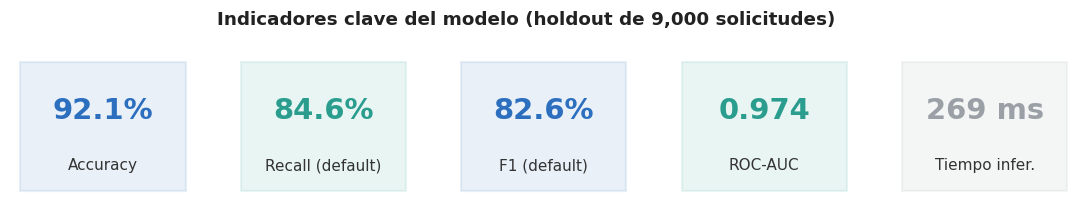

KPIs guardados en output/resumen_kpis.json


In [3]:
kpis = [
    ("Accuracy",  f"{metricas['accuracy']*100:.1f}%",  AZUL),
    ("Recall (default)", f"{metricas['recall']*100:.1f}%", VERDE),
    ("F1 (default)", f"{metricas['f1_score']*100:.1f}%", AZUL),
    ("ROC-AUC",  f"{metricas['roc_auc']:.3f}", VERDE),
    ("Tiempo infer.", f"{t_infer*1000:.0f} ms", GRIS),
]

fig, axes = plt.subplots(1, len(kpis), figsize=(2.5 * len(kpis), 1.9))
for ax, (etq, val, color) in zip(axes, kpis):
    ax.axis("off")
    ax.add_patch(plt.Rectangle((0.05, 0.10), 0.90, 0.80, transform=ax.transAxes,
                               facecolor=color, alpha=0.10, edgecolor=color, lw=1.4, zorder=0))
    ax.text(0.5, 0.60, val, transform=ax.transAxes, ha="center", va="center",
            fontsize=19, fontweight="bold", color=color)
    ax.text(0.5, 0.26, etq, transform=ax.transAxes, ha="center", va="center",
            fontsize=10, color="#333")
fig.suptitle("Indicadores clave del modelo (holdout de {:,} solicitudes)".format(len(X_test)),
             fontsize=12, fontweight="bold", y=1.05)
guardar(fig, "01_kpis")
plt.show()

# Persistir KPIs como resultado estructurado
resumen = {k: round(metricas[k], 4) for k in ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']}
resumen["tiempo_inferencia_ms"] = round(t_infer * 1000, 2)
resumen["n_holdout"] = int(len(X_test))
resumen["generado"] = dt.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
(OUT / "resumen_kpis.json").write_text(json.dumps(resumen, indent=2, ensure_ascii=False), encoding="utf-8")
print("KPIs guardados en output/resumen_kpis.json")

## 3 · Volumen de datos procesado por etapa (flujo operativo)

Cuántos registros entran en la ingesta, cuántos se descartan en la limpieza y cuántos llegan al
modelo. Permite detectar **cuellos de botella**. Los conteos se leen de las salidas reales de cada
etapa (CSV intermedios + holdout). → *Gráfico de barras (embudo)*.

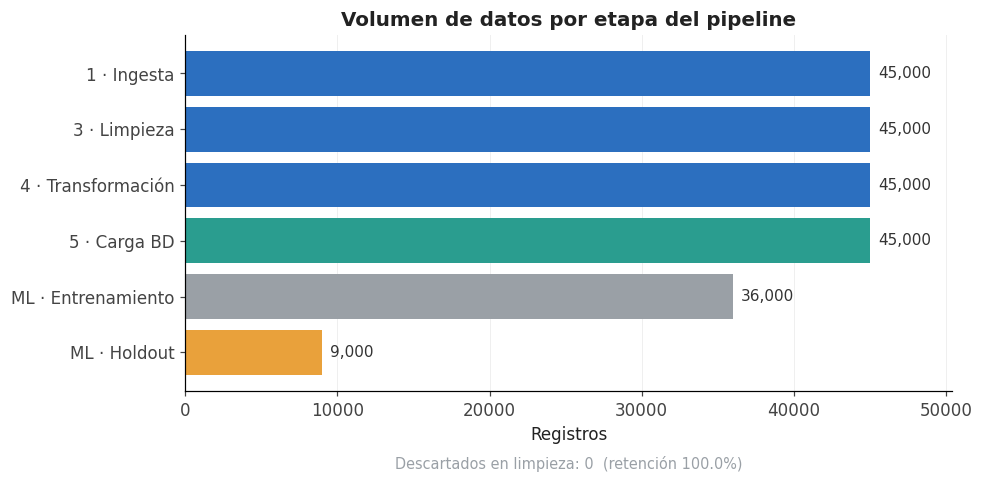

             etapa  filas
       1 · Ingesta  45000
      3 · Limpieza  45000
4 · Transformación  45000
      5 · Carga BD  45000
ML · Entrenamiento  36000
      ML · Holdout   9000


In [4]:
def contar_csv(ruta: Path):
    return len(pd.read_csv(ruta)) if ruta.exists() else None

n_ingesta = contar_csv(DATA / "loan_data_raw.csv")
n_limpieza = contar_csv(DATA / "loan_data_clean.csv")
n_transf = contar_csv(DATA / "loan_data_transformed.csv")
n_bd = int(len(df))                    # filas en el destino (BD o CSV final)
n_test = int(len(X_test))              # holdout que evalúa el modelo
n_train = n_transf - n_test if n_transf else None

etapas = pd.DataFrame({
    "etapa": ["1 · Ingesta", "3 · Limpieza", "4 · Transformación",
              "5 · Carga BD", "ML · Entrenamiento", "ML · Holdout"],
    "filas": [n_ingesta, n_limpieza, n_transf, n_bd, n_train, n_test],
})
etapas.to_csv(OUT / "volumen_pipeline.csv", index=False)

colores = [AZUL, AZUL, AZUL, VERDE, GRIS, NARANJA]
fig, ax = plt.subplots(figsize=(9, 4.2))
barras = ax.barh(etapas["etapa"], etapas["filas"], color=colores)
ax.invert_yaxis()                      # flujo de arriba hacia abajo
ax.set_xlabel("Registros")
ax.set_title("Volumen de datos por etapa del pipeline")
ax.margins(x=0.12)
ax.grid(axis="y", visible=False)
etiquetar_barras(ax, barras, fmt="{:,.0f}", horizontal=True, fontsize=10, color="#333")

# Anotar registros descartados en la limpieza (único punto que reduce filas)
descartados = (n_ingesta - n_limpieza) if (n_ingesta and n_limpieza) else 0
ax.annotate(f"Descartados en limpieza: {descartados:,}  (retención {n_limpieza/n_ingesta:.1%})",
            xy=(0.5, -0.22), xycoords="axes fraction", ha="center",
            fontsize=9.5, color=ROJO if descartados else GRIS)
guardar(fig, "02_volumen_etapas")
plt.show()
print(etapas.to_string(index=False))

## 4 · Métricas de calidad del modelo

Comparación de las métricas de calidad en una escala común (0–100 %) para ver *en un vistazo* si el
modelo opera correctamente. El **tiempo de ejecución** va aparte por tener otra unidad.
→ *Gráfico de barras + KPI*.

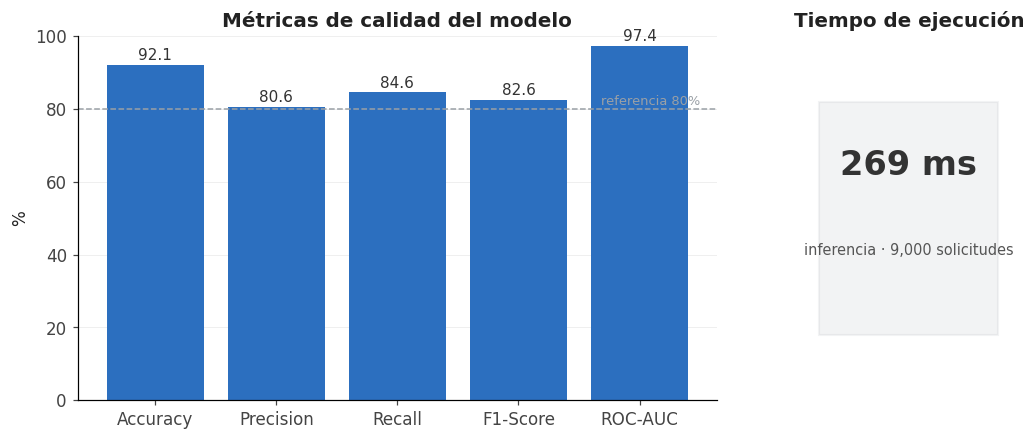

In [5]:
nombres = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
claves = ["accuracy", "precision", "recall", "f1_score", "roc_auc"]
valores = [metricas[c] * 100 for c in claves]

fig, (ax, axt) = plt.subplots(1, 2, figsize=(11, 4.3), gridspec_kw={"width_ratios": [3, 1]})

barras = ax.bar(nombres, valores, color=AZUL)
ax.axhline(80, color=GRIS, lw=1, ls="--")
ax.text(len(nombres) - 0.5, 81, "referencia 80%", color=GRIS, fontsize=8.5, ha="right")
ax.set_ylim(0, 100)
ax.set_ylabel("%")
ax.set_title("Métricas de calidad del modelo")
ax.grid(axis="x", visible=False)
etiquetar_barras(ax, barras, fmt="{:.1f}", fontsize=10, color="#333")

# Tiempo de ejecución como KPI dedicado
axt.axis("off")
axt.add_patch(plt.Rectangle((0.08, 0.18), 0.84, 0.64, transform=axt.transAxes,
                            facecolor=GRIS, alpha=0.12, edgecolor=GRIS, lw=1.4))
axt.text(0.5, 0.62, f"{t_infer*1000:.0f} ms", transform=axt.transAxes,
         ha="center", fontsize=22, fontweight="bold", color="#333")
axt.text(0.5, 0.40, f"inferencia · {len(X_test):,} solicitudes", transform=axt.transAxes,
         ha="center", fontsize=9.5, color="#555")
axt.set_title("Tiempo de ejecución")
guardar(fig, "03_metricas_calidad")
plt.show()

## 5 · Matriz de confusión

Aciertos (diagonal) vs. errores (fuera de la diagonal), con colores semánticos: **verde = acierto**,
**rojo = error**. Cada celda muestra el conteo y el % por clase real. → *Heatmap*.

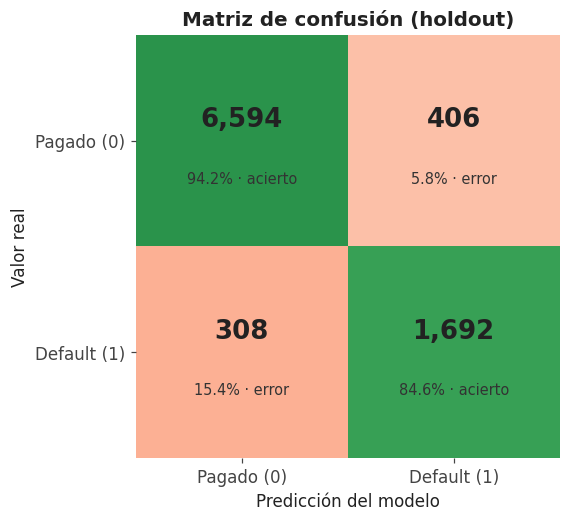

Verdaderos negativos: 6,594 | Falsos positivos: 406
Falsos negativos:     308 | Verdaderos positivos: 1,692


In [6]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
etiquetas = ["Pagado (0)", "Default (1)"]

# Color por significado: diagonal en verde, fuera de la diagonal en rojo,
# con intensidad proporcional al % de la fila (clase real).
rgba = np.zeros((2, 2, 4))
for i in range(2):
    for j in range(2):
        cmap = plt.cm.Greens if i == j else plt.cm.Reds
        rgba[i, j] = cmap(0.20 + 0.55 * cm_norm[i, j])

fig, ax = plt.subplots(figsize=(5.8, 5))
ax.imshow(rgba, aspect="equal")
ax.set_xticks([0, 1], etiquetas)
ax.set_yticks([0, 1], etiquetas)
ax.set_xlabel("Predicción del modelo")
ax.set_ylabel("Valor real")
ax.set_title("Matriz de confusión (holdout)")
for s in ax.spines.values():
    s.set_visible(False)
ax.grid(False)
for i in range(2):
    for j in range(2):
        tipo = "acierto" if i == j else "error"
        ax.text(j, i - 0.10, f"{cm[i, j]:,}", ha="center", va="center",
                fontsize=17, fontweight="bold", color="#222")
        ax.text(j, i + 0.18, f"{cm_norm[i, j]:.1%} · {tipo}", ha="center", va="center",
                fontsize=9.5, color="#333")
guardar(fig, "04_matriz_confusion")
plt.show()

vn, fp, fn, vp = cm.ravel()
print(f"Verdaderos negativos: {vn:,} | Falsos positivos: {fp:,}")
print(f"Falsos negativos:     {fn:,} | Verdaderos positivos: {vp:,}")

## 6 · Distribución de clases: real vs. predicho

Compara cuántas solicitudes hay por categoría en la realidad y cuántas predice el modelo. Sirve para
detectar **sesgos o desequilibrios** en las predicciones. → *Gráfico de barras*.

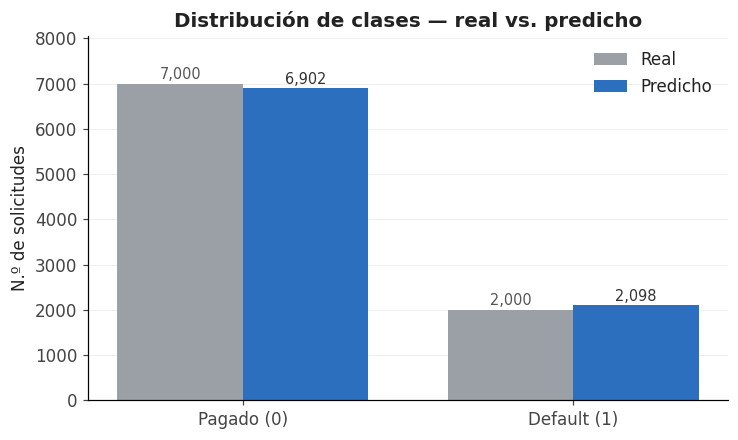

Defaults reales: 2,000 | predichos: 2,098 (sobreestimación 4.9%)


In [7]:
real = pd.Series(y_test).value_counts().reindex([0, 1]).fillna(0).astype(int)
pred = pd.Series(y_pred).value_counts().reindex([0, 1]).fillna(0).astype(int)
clases = ["Pagado (0)", "Default (1)"]
x = np.arange(len(clases))
w = 0.38

fig, ax = plt.subplots(figsize=(7.5, 4.3))
b1 = ax.bar(x - w / 2, real.values, w, label="Real", color=GRIS)
b2 = ax.bar(x + w / 2, pred.values, w, label="Predicho", color=AZUL)
ax.set_xticks(x, clases)
ax.set_ylabel("N.º de solicitudes")
ax.set_title("Distribución de clases — real vs. predicho")
ax.grid(axis="x", visible=False)
ax.legend(frameon=False)
ax.margins(y=0.15)
etiquetar_barras(ax, b1, fmt="{:,.0f}", fontsize=9.5, color="#555")
etiquetar_barras(ax, b2, fmt="{:,.0f}", fontsize=9.5, color="#333")
guardar(fig, "05_distribucion_clases")
plt.show()

sesgo = (pred[1] - real[1]) / real[1]
print(f"Defaults reales: {real[1]:,} | predichos: {pred[1]:,} "
      f"({'sobre' if sesgo > 0 else 'sub'}estimación {abs(sesgo):.1%})")

## 7 · Evolución del rendimiento

Dos lecturas complementarias, ambas alimentadas automáticamente:

**A. Curva de aprendizaje** — rendimiento del modelo (Accuracy y ROC-AUC) según el **volumen de datos
de entrenamiento**. Reentrena el mismo modelo (idéntica configuración) sobre fracciones crecientes y
evalúa en el holdout fijo. Permite ver mejoras y dónde se estabiliza (plateau). → *Gráfico de líneas*.

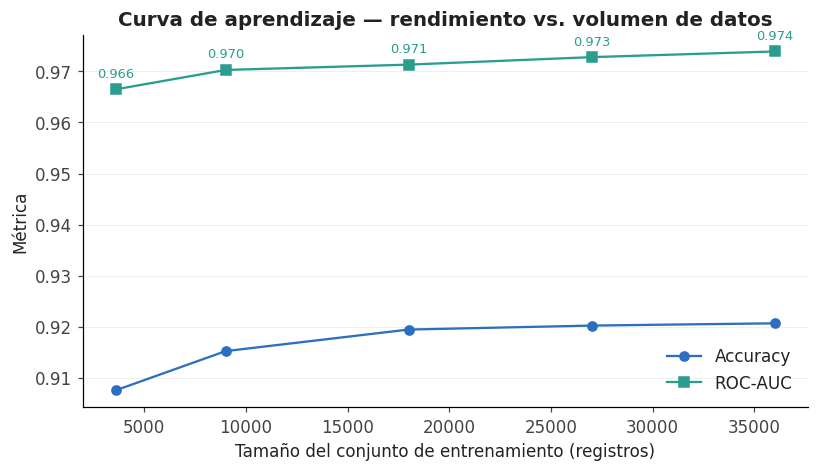

 n_entrenamiento  accuracy  roc_auc  f1_score
            3600    0.9076   0.9665    0.8058
            9000    0.9152   0.9703    0.8159
           18000    0.9194   0.9713    0.8223
           27000    0.9202   0.9728    0.8249
           36000    0.9207   0.9739    0.8258


In [8]:
# Reproduce el split del entrenamiento (mismo random_state) y construye la curva
X = df[FEATURES]
y = df[TARGET]
X_tr, X_ev, y_tr, y_ev = train_test_split(X, y, test_size=0.2, random_state=29, stratify=y)

fracciones = [0.1, 0.25, 0.5, 0.75, 1.0]
filas = []
for fr in fracciones:
    if fr < 1.0:
        Xi, _, yi, _ = train_test_split(X_tr, y_tr, train_size=fr, random_state=29, stratify=y_tr)
    else:
        Xi, yi = X_tr, y_tr
    m = clone(modelo)
    m.fit(Xi, yi)
    p = m.predict(X_ev)
    pr = m.predict_proba(X_ev)[:, 1]
    filas.append({
        "n_entrenamiento": len(Xi),
        "accuracy": accuracy_score(y_ev, p),
        "roc_auc": roc_auc_score(y_ev, pr),
        "f1_score": f1_score(y_ev, p),
    })

curva = pd.DataFrame(filas)
curva.to_csv(OUT / "curva_aprendizaje.csv", index=False)

fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.plot(curva["n_entrenamiento"], curva["accuracy"], marker="o", color=AZUL, label="Accuracy")
ax.plot(curva["n_entrenamiento"], curva["roc_auc"], marker="s", color=VERDE, label="ROC-AUC")
ax.set_xlabel("Tamaño del conjunto de entrenamiento (registros)")
ax.set_ylabel("Métrica")
ax.set_title("Curva de aprendizaje — rendimiento vs. volumen de datos")
ax.grid(axis="x", visible=False)
ax.legend(frameon=False)
for _, r in curva.iterrows():
    ax.annotate(f"{r['roc_auc']:.3f}", (r["n_entrenamiento"], r["roc_auc"]),
                textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8.5, color=VERDE)
guardar(fig, "06a_curva_aprendizaje")
plt.show()
print(curva.round(4).to_string(index=False))

**B. Histórico por corrida** — cada ejecución de este cuaderno registra automáticamente sus métricas
con marca de tiempo en `output/historico_evaluaciones.csv`. Así se monitorea el rendimiento **en el
tiempo / por versión** y se detectan caídas (degradación) entre corridas. → *Gráfico de líneas*.

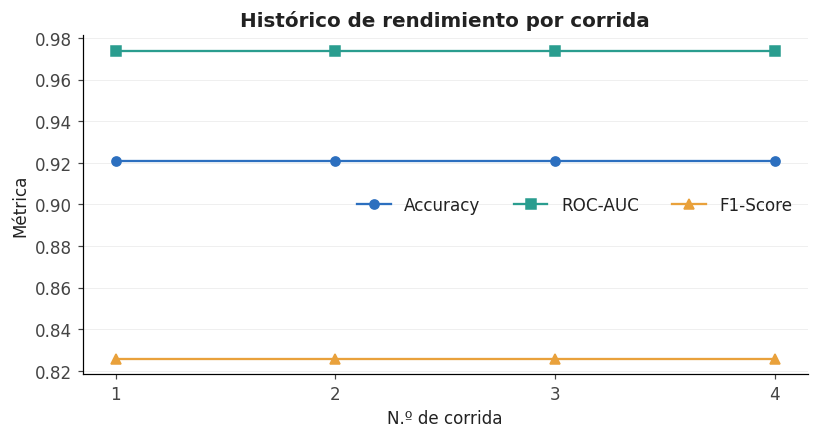

Corridas registradas: 4 (output/historico_evaluaciones.csv)


In [9]:
hist_path = OUT / "historico_evaluaciones.csv"
fila = {
    "timestamp": dt.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "n_holdout": int(len(X_test)),
    **{k: round(metricas[k], 4) for k in ["accuracy", "precision", "recall", "f1_score", "roc_auc"]},
}
hist = pd.read_csv(hist_path) if hist_path.exists() else pd.DataFrame()
hist = pd.concat([hist, pd.DataFrame([fila])], ignore_index=True)
hist.to_csv(hist_path, index=False)

fig, ax = plt.subplots(figsize=(8.5, 4))
ejex = range(1, len(hist) + 1)
ax.plot(ejex, hist["accuracy"], marker="o", color=AZUL, label="Accuracy")
ax.plot(ejex, hist["roc_auc"], marker="s", color=VERDE, label="ROC-AUC")
ax.plot(ejex, hist["f1_score"], marker="^", color=NARANJA, label="F1-Score")
ax.set_xticks(list(ejex))
ax.set_xlabel("N.º de corrida")
ax.set_ylabel("Métrica")
ax.set_title("Histórico de rendimiento por corrida")
ax.grid(axis="x", visible=False)
ax.legend(frameon=False, ncol=3)
if len(hist) == 1:
    ax.set_ylim(0, 1.05)
    ax.text(1, 0.5, "  1.ª corrida registrada.\n  Se acumula automáticamente\n  en cada ejecución.",
            fontsize=9, color=GRIS, va="center")
guardar(fig, "06b_historico_rendimiento")
plt.show()
print(f"Corridas registradas: {len(hist)} (output/historico_evaluaciones.csv)")

## 8 · Casos erróneos (tabla filtrable)

Registros del holdout donde el modelo se equivocó, clasificados en **Falso Positivo** (predijo default
y pagó) y **Falso Negativo** (predijo pago e hizo default). Se guardan en `output/casos_erroneos.csv`
(filtrable en cualquier herramienta) y se ofrece un filtro interactivo. → *Tabla filtrable*.

In [10]:
casos = X_test.copy()
casos.insert(0, "id_holdout", range(len(casos)))
casos["real"] = np.asarray(y_test)
casos["prediccion"] = y_pred
casos["prob_default"] = y_prob.round(4)
err = casos[casos["real"] != casos["prediccion"]].copy()
err["tipo_error"] = np.where((err["real"] == 0) & (err["prediccion"] == 1),
                             "Falso Positivo (FP)", "Falso Negativo (FN)")
cols = ["id_holdout", "tipo_error", "prob_default", "real", "prediccion"] + FEATURES
err = err[cols].sort_values("prob_default", ascending=False).reset_index(drop=True)
err.to_csv(OUT / "casos_erroneos.csv", index=False)

resumen_err = err["tipo_error"].value_counts()
print(f"Total de casos erróneos: {len(err):,} de {len(casos):,} ({len(err)/len(casos):.1%})")
print(resumen_err.to_string())
print("\\nGuardado en output/casos_erroneos.csv")


def filtrar_casos(tipo=None, prob_min=0.0, n=20):
    '''Filtro programático de la tabla de errores (alternativa a la versión interactiva).'''
    d = err if tipo is None else err[err["tipo_error"] == tipo]
    return d[d["prob_default"] >= prob_min].head(n)


filtrar_casos(n=10)

Total de casos erróneos: 714 de 9,000 (7.9%)
tipo_error
Falso Positivo (FP)    406
Falso Negativo (FN)    308
\nGuardado en output/casos_erroneos.csv


,id_holdout,tipo_error,prob_default,real,prediccion,person_age,person_gender,person_education,person_income,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,has_prev_defaults
0,415,Falso Positivo (FP),0.980,0,1,31.0,male,High School,36909.0,RENT,7200.0,VENTURE,15.76,0.20,7.0,624,0
1,1119,Falso Positivo (FP),0.960,0,1,24.0,female,Bachelor,38101.0,RENT,7000.0,EDUCATION,15.66,0.18,4.0,649,0
2,5356,Falso Positivo (FP),0.950,0,1,23.0,female,Master,39562.0,RENT,2428.0,HOMEIMPROVEMENT,12.20,0.06,4.0,643,0
3,642,Falso Positivo (FP),0.940,0,1,22.0,female,High School,28366.7,RENT,2850.0,MEDICAL,15.27,0.12,4.0,599,0
4,3474,Falso Positivo (FP),0.940,0,1,24.0,male,Associate,35602.0,RENT,6000.0,MEDICAL,15.27,0.17,2.0,609,0
5,4192,Falso Positivo (FP),0.935,0,1,30.0,male,Associate,87382.0,MORTGAGE,9000.0,MEDICAL,15.20,0.10,10.0,642,0
6,3206,Falso Positivo (FP),0.930,0,1,29.0,female,High School,55034.0,RENT,9000.0,DEBTCONSOLIDATION,14.55,0.16,6.0,659,0
7,2557,Falso Positivo (FP),0.930,0,1,27.0,male,Bachelor,80180.0,RENT,20000.0,DEBTCONSOLIDATION,10.62,0.25,9.0,708,0
8,1025,Falso Positivo (FP),0.930,0,1,25.0,female,Bachelor,45038.0,RENT,9172.0,MEDICAL,14.69,0.20,5.0,596,0
9,1711,Falso Positivo (FP),0.925,0,1,22.0,male,High School,32877.0,RENT,3500.0,PERSONAL,15.27,0.11,3.0,659,0


In [11]:
# Filtro interactivo (ipywidgets). En la versión estática se muestran los controles;
# para usarlos en vivo, abrir el cuaderno en Jupyter. Alternativa: filtrar_casos(...).
try:
    import ipywidgets as widgets
    from IPython.display import display

    opciones = ["Todos"] + sorted(err["tipo_error"].unique().tolist())

    @widgets.interact(
        tipo=widgets.Dropdown(options=opciones, value="Todos", description="Tipo:"),
        prob_min=widgets.FloatSlider(value=0.0, min=0.0, max=1.0, step=0.05, description="Prob ≥"),
        filas=widgets.IntSlider(value=15, min=5, max=50, step=5, description="Filas:"),
    )
    def _filtro(tipo, prob_min, filas):
        d = err if tipo == "Todos" else err[err["tipo_error"] == tipo]
        d = d[d["prob_default"] >= prob_min]
        print(f"{len(d):,} casos coinciden")
        display(d.head(filas))
except Exception as exc:
    print(f"ipywidgets no disponible ({type(exc).__name__}); usa filtrar_casos(tipo=..., prob_min=...).")

interactive(children=(Dropdown(description='Tipo:', options=('Todos', 'Falso Negativo (FN)', 'Falso Positivo (…

## 9 · Cierre — cobertura de los requisitos

| Requisito de la rúbrica | Gráfico exigido | Sección | Artefacto en `output/` |
|---|---|---|---|
| Matriz de confusión | Heatmap | 5 | `04_matriz_confusion.png` |
| Métricas (Accuracy/Recall/F1/Tiempo) | Barras / KPI | 2, 4 | `01_kpis.png`, `03_metricas_calidad.png` |
| Distribución de clases | Barras / Pie | 6 | `05_distribucion_clases.png` |
| Evolución del rendimiento | Líneas / Áreas | 7 | `06a_curva_aprendizaje.png`, `06b_historico_rendimiento.png` |
| Casos erróneos | Tabla filtrable | 8 | `casos_erroneos.csv` |
| Volumen por etapa | Barras / KPI | 3 | `02_volumen_etapas.png`, `volumen_pipeline.csv` |

**Diseño:** data-ink ratio (sin bordes/rejillas redundantes, etiquetas directas) y simplicidad visual
(paleta semántica, sin 3D ni adornos).
**Automatización:** todo se lee de las salidas reales del pipeline/modelo (BD, CSV, `.json`, `.pkl`) y
los resultados se guardan automáticamente en `visualizaciones/output/`. Reejecutar el cuaderno
actualiza las figuras y tablas sin intervención manual.